# nb16 — RNA-Protein Deviation Characterization

Using per-protein Pearson r from masked_l1_1e4 (nb15) as RNA-protein coupling score.
Classify proteins into RNA-coupled vs RNA-independent, then characterize deviations
by tissue and cross-reference with drug response signal.

Inputs:
- `results/rna_to_protein/armB2_per_protein.csv` — per-protein Pearson r from nb15
- `data/processed/nb14_protein_ic50_correlations.csv` — protein-IC50 correlations from nb14
- `data/GDSC2/proteomics.csv` — raw protein matrix
- `data/GDSC2/gene_expression.csv` — raw RNA matrix
- `data/splits/splits.json` — LCO splits

Outputs:
- `results/deviation/protein_classification.csv` — coupled vs independent per protein
- `results/deviation/tissue_coupling_profile.csv` — median coupling score per tissue
- `results/deviation/high_deviation_drug_relevant.csv` — RNA-independent + IC50-correlated proteins

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/multiomics_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Mounted at /content/drive
Running on Colab | BASE_PATH = /content/drive/MyDrive/multiomics_project


## Imports and config

In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

In [3]:
DATA_DIR      = BASE_PATH / 'data' / 'GDSC2'
PROCESSED_DIR = BASE_PATH / 'data' / 'processed'
SPLITS_DIR    = BASE_PATH / 'data' / 'splits'
NB15_DIR      = BASE_PATH / 'results' / 'rna_to_protein'
RESULTS_DIR   = BASE_PATH / 'results' / 'deviation'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

COL_CELLOSAURUS = 'cellosaurus_id'
COL_TISSUE      = 'tissue'

# Coupling thresholds
COUPLED_R_THRESHOLD     = 0.3   # protein well-predicted by RNA
INDEPENDENT_R_THRESHOLD = 0.1   # protein poorly predicted by RNA

# IC50 correlation threshold for drug relevance
IC50_CORR_THRESHOLD = 0.2

## Load data

In [4]:
# Per-protein coupling scores from nb15 (masked_l1_1e4)
coupling_df = pd.read_csv(NB15_DIR / 'armB2_per_protein.csv')
print(f'Proteins from nb15: {len(coupling_df):,}')
print(coupling_df.head(3))

Proteins from nb15: 6,651
              protein  pearson_r        r2  n_observed
0  P37108;SRP14_HUMAN   0.177254 -1.392061          84
1  Q96JP5;ZFP91_HUMAN   0.071364 -0.510535          53
2   Q9Y4H2;IRS2_HUMAN   0.184369  0.019612          20


In [5]:
# Raw omics matrices
rna     = pd.read_csv(DATA_DIR / 'gene_expression.csv',  index_col=0)
protein = pd.read_csv(DATA_DIR / 'proteomics.csv',        index_col=0)

rna     = rna[~rna.index.duplicated(keep='first')].iloc[:, 1:]
protein = protein[~protein.index.duplicated(keep='first')]

print(f'RNA:     {rna.shape}')
print(f'Protein: {protein.shape}')

RNA:     (1010, 17737)
Protein: (860, 6692)


In [6]:
# Response pairs (for tissue labels)
pairs = pd.read_parquet(PROCESSED_DIR / 'response_pairs.parquet')
cell_tissue = (
    pairs[[COL_CELLOSAURUS, COL_TISSUE]]
    .drop_duplicates(COL_CELLOSAURUS)
    .set_index(COL_CELLOSAURUS)
)
print(f'Cell lines with tissue labels: {len(cell_tissue):,}')
print(f'Tissues: {cell_tissue[COL_TISSUE].nunique()}')

Cell lines with tissue labels: 836
Tissues: 26


In [7]:
# LCO splits — use fold 0 train cell lines for deviation analysis
# (same cell lines the nb15 model was trained on — no leakage)
with open(SPLITS_DIR / 'splits.json') as f:
    folds = json.load(f)

fold         = folds[0]
train_pairs  = pairs.loc[fold['train']]
test_pairs   = pairs.loc[fold['lco_test']]
train_cells  = train_pairs[COL_CELLOSAURUS].unique().tolist()
test_cells   = test_pairs[COL_CELLOSAURUS].unique().tolist()

print(f'Train cell lines: {len(train_cells):,}')
print(f'Test  cell lines: {len(test_cells):,}')

Train cell lines: 643
Test  cell lines: 84


## Step 1 — Classify proteins by RNA-coupling

Use per-protein Pearson r from nb15 masked_l1_1e4 as the coupling score.
Three classes:
- **coupled**: r ≥ 0.3 — RNA explains protein well
- **intermediate**: 0.1 ≤ r < 0.3
- **independent**: r < 0.1 — protein is largely independent of RNA

In [8]:
def classify_coupling(r: float) -> str:
    if pd.isna(r):
        return 'independent'  # NaN = zero variance in test = no coupling signal
    if r >= COUPLED_R_THRESHOLD:
        return 'coupled'
    if r >= INDEPENDENT_R_THRESHOLD:
        return 'intermediate'
    return 'independent'


coupling_df['coupling_class'] = coupling_df['pearson_r'].apply(classify_coupling)

counts = coupling_df['coupling_class'].value_counts()
print('Protein coupling classification:')
for cls, n in counts.items():
    print(f'  {cls:15s}: {n:,} ({n/len(coupling_df)*100:.1f}%)')

Protein coupling classification:
  independent    : 5,403 (81.2%)
  intermediate   : 910 (13.7%)
  coupled        : 338 (5.1%)


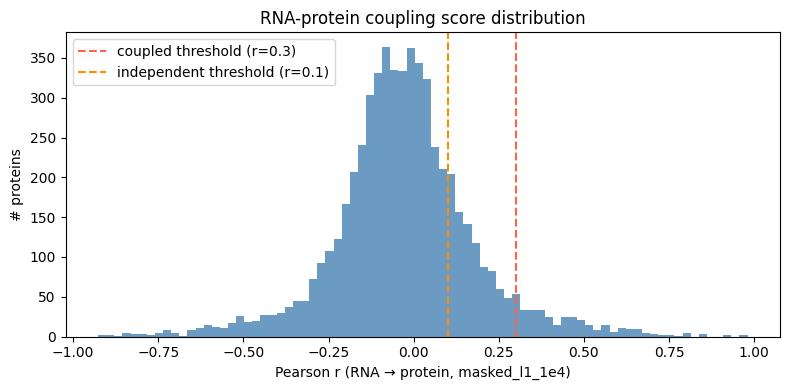

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
r_vals = coupling_df['pearson_r'].dropna()
ax.hist(r_vals, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(COUPLED_R_THRESHOLD,     color='tomato',   linewidth=1.5, linestyle='--',
           label=f'coupled threshold (r={COUPLED_R_THRESHOLD})')
ax.axvline(INDEPENDENT_R_THRESHOLD, color='darkorange', linewidth=1.5, linestyle='--',
           label=f'independent threshold (r={INDEPENDENT_R_THRESHOLD})')
ax.set_xlabel('Pearson r (RNA → protein, masked_l1_1e4)')
ax.set_ylabel('# proteins')
ax.set_title('RNA-protein coupling score distribution')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'coupling_score_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 2 — Per-gene linear deviation

For each protein in the RNA-independent class: fit `protein ~ RNA_same_gene` across
train cell lines. Residual std = deviation magnitude. R² = how much RNA explains.
This gives a gene-level predictability score independent of the DL model.

In [10]:
# Build aligned RNA and protein matrices on train cell lines
common_train_cells = [
    c for c in train_cells
    if c in rna.index and c in protein.index
]
print(f'Train cell lines with both RNA and protein: {len(common_train_cells):,}')

rna_tr     = rna.loc[common_train_cells]
protein_tr = protein.loc[common_train_cells]

Train cell lines with both RNA and protein: 643


In [11]:
def gene_symbol(protein_col: str) -> str:
    """Extract gene symbol from ProCan column name (e.g. 'Q9BVC5;ASHWN_HUMAN' -> 'ASHWN')."""
    if ';' in protein_col:
        part = protein_col.split(';')[1]
        return part.split('_')[0]
    return protein_col


def compute_linear_deviation(protein_col: str,
                              rna_df: pd.DataFrame,
                              protein_df: pd.DataFrame) -> dict:
    """Fit protein ~ RNA_same_gene across cell lines.
    Returns slope, R², residual std, n_observed.
    """
    gene = gene_symbol(protein_col)

    # Match gene symbol to RNA column
    rna_cols = [c for c in rna_df.columns if c.startswith(gene + ' ') or c == gene]
    if not rna_cols:
        return {'protein': protein_col, 'gene': gene, 'rna_col': None,
                'slope': np.nan, 'r2': np.nan, 'residual_std': np.nan, 'n_observed': 0}

    rna_col   = rna_cols[0]
    y         = protein_df[protein_col].values.astype(float)
    x         = rna_df[rna_col].values.astype(float)

    # Keep only rows where both are observed
    valid = ~(np.isnan(x) | np.isnan(y))
    if valid.sum() < 10:
        return {'protein': protein_col, 'gene': gene, 'rna_col': rna_col,
                'slope': np.nan, 'r2': np.nan, 'residual_std': np.nan,
                'n_observed': valid.sum()}

    x_fit, y_fit = x[valid].reshape(-1, 1), y[valid]
    model        = LinearRegression().fit(x_fit, y_fit)
    y_pred       = model.predict(x_fit)
    residuals    = y_fit - y_pred

    return {
        'protein':      protein_col,
        'gene':         gene,
        'rna_col':      rna_col,
        'slope':        model.coef_[0],
        'r2':           r2_score(y_fit, y_pred),
        'residual_std': residuals.std(),
        'n_observed':   valid.sum(),
    }

In [12]:
# Run on all proteins (not just independent — gives full picture for comparison)
# Subset protein columns to those that exist in protein_tr
protein_cols_available = [
    p for p in coupling_df['protein'].tolist()
    if p in protein_tr.columns
]
print(f'Proteins to compute linear deviation for: {len(protein_cols_available):,}')

deviation_rows = []
for i, pcol in enumerate(protein_cols_available):
    deviation_rows.append(compute_linear_deviation(pcol, rna_tr, protein_tr))
    if (i + 1) % 500 == 0:
        print(f'  {i+1:,} / {len(protein_cols_available):,}')

deviation_df = pd.DataFrame(deviation_rows)
print(f'Done. Shape: {deviation_df.shape}')

Proteins to compute linear deviation for: 6,651
  500 / 6,651
  1,000 / 6,651
  1,500 / 6,651
  2,000 / 6,651
  2,500 / 6,651
  3,000 / 6,651
  3,500 / 6,651
  4,000 / 6,651
  4,500 / 6,651
  5,000 / 6,651
  5,500 / 6,651
  6,000 / 6,651
  6,500 / 6,651
Done. Shape: (6651, 7)


In [14]:
deviation_df

,protein,gene,rna_col,slope,r2,residual_std,n_observed
0,P37108;SRP14_HUMAN,SRP14,SRP14,0.673736,0.182910,0.541142,643
1,Q96JP5;ZFP91_HUMAN,ZFP91,None,NaN,NaN,NaN,0
2,Q9Y4H2;IRS2_HUMAN,IRS2,IRS2,0.392579,0.235233,0.782172,120
3,P36578;RL4_HUMAN,RL4,None,NaN,NaN,NaN,0
4,Q6SPF0;SAMD1_HUMAN,SAMD1,SAMD1,0.768924,0.202056,0.739382,487
...,...,...,...,...,...,...,...
6646,Q7Z3B1;NEGR1_HUMAN,NEGR1,NEGR1,0.816437,0.334312,0.945655,87
6647,O60669;MOT2_HUMAN,MOT2,None,NaN,NaN,NaN,0
6648,Q13571;LAPM5_HUMAN,LAPM5,None,NaN,NaN,NaN,0
6649,Q96JM2;ZN462_HUMAN,ZN462,None,NaN,NaN,NaN,0


In [15]:
protein_df_full

,protein,pearson_r,r2_x,n_observed_x,coupling_class,gene,rna_col,slope,r2_y,residual_std,n_observed_y
0,P37108;SRP14_HUMAN,0.177254,-1.392061,84,intermediate,SRP14,SRP14,0.673736,0.182910,0.541142,643
1,Q96JP5;ZFP91_HUMAN,0.071364,-0.510535,53,independent,ZFP91,None,NaN,NaN,NaN,0
2,Q9Y4H2;IRS2_HUMAN,0.184369,0.019612,20,intermediate,IRS2,IRS2,0.392579,0.235233,0.782172,120
3,P36578;RL4_HUMAN,-0.003590,-2.355834,84,independent,RL4,None,NaN,NaN,NaN,0
4,Q6SPF0;SAMD1_HUMAN,0.159552,-0.211510,63,intermediate,SAMD1,SAMD1,0.768924,0.202056,0.739382,487
...,...,...,...,...,...,...,...,...,...,...,...
6646,Q7Z3B1;NEGR1_HUMAN,0.233360,-2.654063,7,intermediate,NEGR1,NEGR1,0.816437,0.334312,0.945655,87
6647,O60669;MOT2_HUMAN,-0.104296,-3.115182,8,independent,MOT2,None,NaN,NaN,NaN,0
6648,Q13571;LAPM5_HUMAN,NaN,NaN,3,independent,LAPM5,None,NaN,NaN,NaN,0
6649,Q96JM2;ZN462_HUMAN,0.327218,-1.974220,9,coupled,ZN462,None,NaN,NaN,NaN,0


In [16]:
# Merge coupling scores with linear deviation stats
protein_df_full = coupling_df.merge(deviation_df, on='protein', how='left')
protein_df_full.to_csv(RESULTS_DIR / 'protein_classification.csv', index=False)

print(f'Proteins with linear deviation computed: {deviation_df["r2"].notna().sum():,}')
print(f'Proteins without RNA match: {deviation_df["r2"].isna().sum():,}')
print()
print('Linear R² summary (protein ~ RNA_same_gene, train cell lines):')
print(protein_df_full['r2_x'].describe().round(3))

Proteins with linear deviation computed: 2,753
Proteins without RNA match: 3,898

Linear R² summary (protein ~ RNA_same_gene, train cell lines):
count    5797.000
mean       -0.901
std         2.103
min       -71.295
25%        -0.956
50%        -0.496
75%        -0.251
max         0.303
Name: r2_x, dtype: float64


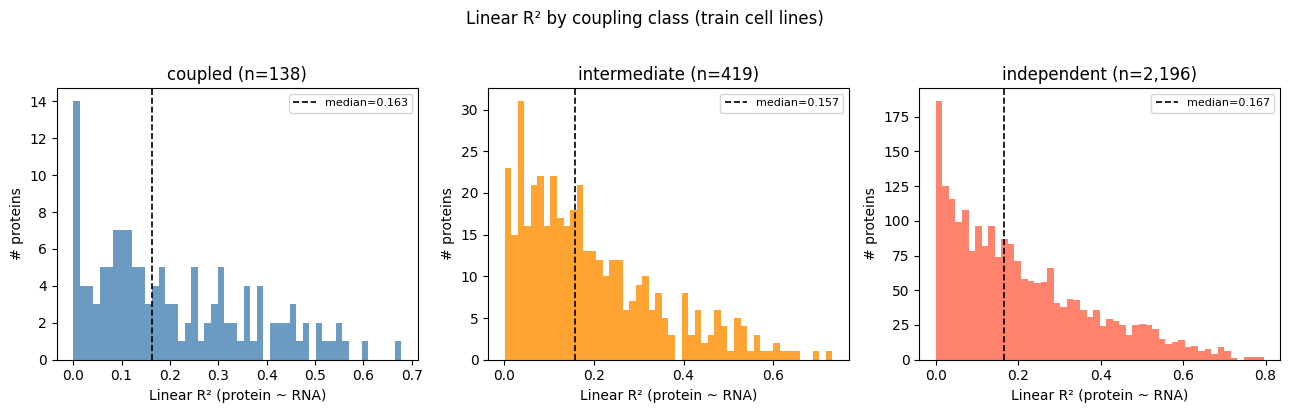

In [19]:
# R² distribution by coupling class
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
classes = ['coupled', 'intermediate', 'independent']
colors  = ['steelblue', 'darkorange', 'tomato']

for ax, cls, col in zip(axes, classes, colors):
    subset = protein_df_full[protein_df_full['coupling_class'] == cls]['r2_y'].dropna()
    ax.hist(subset.clip(-1, 1), bins=50, color=col, edgecolor='none', alpha=0.8)
    ax.set_title(f'{cls} (n={len(subset):,})')
    ax.set_xlabel('Linear R² (protein ~ RNA)')
    ax.set_ylabel('# proteins')
    ax.axvline(subset.median(), color='black', linewidth=1.2, linestyle='--',
               label=f'median={subset.median():.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Linear R² by coupling class (train cell lines)', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'r2_by_coupling_class.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 3 — Tissue stratification

For each tissue type: compute the median coupling score across all proteins.
Identifies which cancer types have the most post-transcriptional dysregulation.

In [20]:
# Build per-cell-line coupling profile:
# for each cell line, compute mean RNA-protein Pearson r across all proteins
# using the raw protein and RNA matrices directly

common_cells = [
    c for c in rna.index
    if c in protein.index and c in cell_tissue.index
]
print(f'Cell lines with RNA + protein + tissue: {len(common_cells):,}')

# Find proteins that have a matched RNA gene
matched_proteins = protein_df_full[
    protein_df_full['rna_col'].notna()
][['protein', 'rna_col', 'coupling_class', 'pearson_r']].copy()
print(f'Proteins with matched RNA gene: {len(matched_proteins):,}')

Cell lines with RNA + protein + tissue: 836
Proteins with matched RNA gene: 2,913


In [21]:
# Per-cell-line: compute mean RNA-protein correlation across matched genes
# Use a sample of proteins for speed (top 1000 by n_observed)
sample_proteins = matched_proteins.nlargest(1000, 'pearson_r').head(500)

cell_coupling_scores = []
rna_sub     = rna.loc[common_cells]
protein_sub = protein.loc[common_cells]

for cell in common_cells:
    rs = []
    for _, row in sample_proteins.iterrows():
        pval = protein_sub.loc[cell, row['protein']] if row['protein'] in protein_sub.columns else np.nan
        rval = rna_sub.loc[cell, row['rna_col']]     if row['rna_col']  in rna_sub.columns     else np.nan
        if not (np.isnan(pval) or np.isnan(rval)):
            rs.append((pval, rval))
    if len(rs) > 10:
        pv, rv = zip(*rs)
        r, _   = pearsonr(pv, rv)
        cell_coupling_scores.append({'cellosaurus_id': cell, 'mean_coupling_r': r})

cell_coupling_df = pd.DataFrame(cell_coupling_scores).set_index('cellosaurus_id')
cell_coupling_df = cell_coupling_df.join(cell_tissue)
print(f'Cell lines with coupling score: {len(cell_coupling_df):,}')

Cell lines with coupling score: 836


In [22]:
# Aggregate by tissue
tissue_coupling = (
    cell_coupling_df
    .groupby(COL_TISSUE)['mean_coupling_r']
    .agg(['median', 'mean', 'count'])
    .rename(columns={'median': 'median_coupling_r', 'mean': 'mean_coupling_r', 'count': 'n_cell_lines'})
    .query('n_cell_lines >= 5')  # at least 5 cell lines per tissue
    .sort_values('median_coupling_r')
)
tissue_coupling.to_csv(RESULTS_DIR / 'tissue_coupling_profile.csv')

print('Tissues with LOWEST RNA-protein coupling (most post-transcriptional dysregulation):')
display(tissue_coupling.head(10).round(3))
print()
print('Tissues with HIGHEST RNA-protein coupling:')
display(tissue_coupling.tail(10).round(3))

Tissues with LOWEST RNA-protein coupling (most post-transcriptional dysregulation):


,median_coupling_r,mean_coupling_r,n_cell_lines
tissue,,,
Head And Neck,0.352,0.345,34
Bladder,0.370,0.376,18
Liver,0.374,0.376,17
Thyroid,0.381,0.367,12
Pancreas,0.383,0.387,23
Brain,0.390,0.390,49
Soft Tissue,0.393,0.403,10
Esophagus,0.400,0.399,34
Ovary,0.404,0.400,39



Tissues with HIGHEST RNA-protein coupling:


,median_coupling_r,mean_coupling_r,n_cell_lines
tissue,,,
Nervous System,0.417,0.421,18
Stomach,0.418,0.404,24
Breast,0.423,0.415,48
Prostate,0.424,0.411,8
Colon,0.425,0.417,44
Bone,0.426,0.421,36
Uterus,0.455,0.427,15
Muscle,0.460,0.463,7
Lymph,0.466,0.460,52


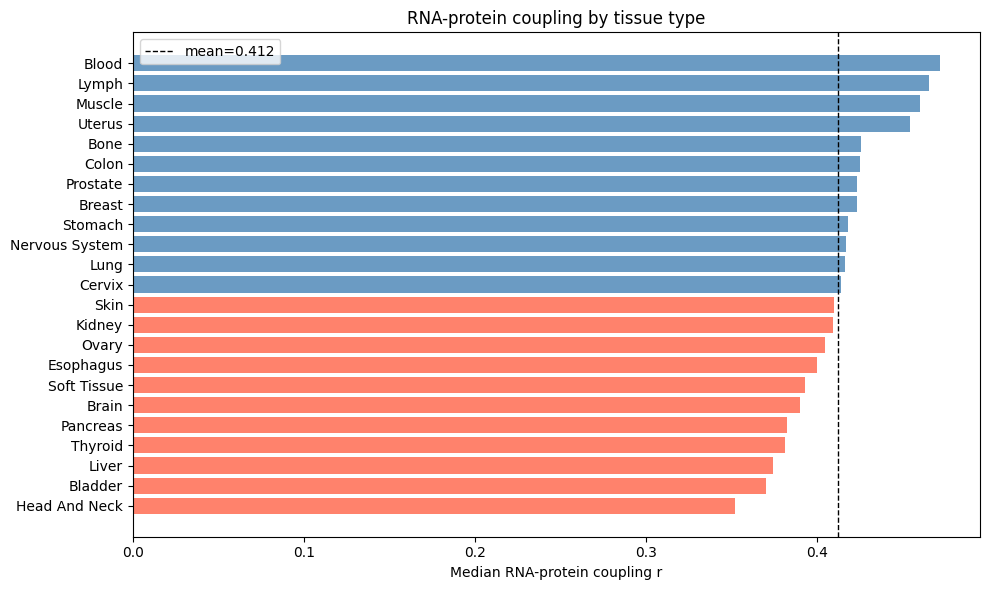

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
tissues = tissue_coupling.index.tolist()
vals    = tissue_coupling['median_coupling_r'].values
colors  = ['tomato' if v < vals.mean() else 'steelblue' for v in vals]

ax.barh(tissues, vals, color=colors, edgecolor='none', alpha=0.8)
ax.axvline(vals.mean(), color='black', linewidth=1, linestyle='--',
           label=f'mean={vals.mean():.3f}')
ax.set_xlabel('Median RNA-protein coupling r')
ax.set_title('RNA-protein coupling by tissue type')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'tissue_coupling_profile.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 4 — Cross-reference with IC50 correlations

Load protein-IC50 correlations from nb14.
Find proteins where: (a) RNA-independent (r < 0.1) AND (b) protein-IC50 |r| > threshold.
These are the biologically most interesting candidates:
post-transcriptionally regulated AND drug-relevant.

In [28]:
COL_DRUG = 'drug_name'

In [29]:
## Step 4 — Compute protein-IC50 correlations (self-contained)
# For each protein: mean |Pearson r| with LN_IC50 across the top 20 most-tested drugs
# Computed on train cell lines only — no leakage

TOP_DRUGS_N   = 20
MIN_PAIRS     = 30   # minimum cell lines with both protein and IC50 for a drug to count

train_pairs_df = pairs.loc[fold['train']]
top_drugs = (
    train_pairs_df[COL_DRUG]
    .value_counts()
    .head(TOP_DRUGS_N)
    .index.tolist()
)
print(f'Top {TOP_DRUGS_N} drugs: {top_drugs[:5]} ...')

Top 20 drugs: ['PLX-4720', 'MIRA-1', '5-Fluorouracil', 'Vorinostat', 'Dactolisib'] ...


In [30]:
def protein_ic50_correlation(protein_col: str,
                              drug: str,
                              train_pairs_df: pd.DataFrame,
                              protein_df: pd.DataFrame) -> float:
    """Pearson r between one protein and IC50 for one drug, on train cell lines."""
    drug_pairs = train_pairs_df[train_pairs_df[COL_DRUG] == drug][
        [COL_CELLOSAURUS, 'LN_IC50']
    ].drop_duplicates(COL_CELLOSAURUS)

    common = drug_pairs[COL_CELLOSAURUS][
        drug_pairs[COL_CELLOSAURUS].isin(protein_df.index)
    ].values

    if len(common) < MIN_PAIRS:
        return np.nan

    p = protein_df.loc[common, protein_col].values.astype(float)
    y = drug_pairs.set_index(COL_CELLOSAURUS).loc[common, 'LN_IC50'].values.astype(float)

    valid = ~(np.isnan(p) | np.isnan(y))
    if valid.sum() < MIN_PAIRS:
        return np.nan

    r, _ = pearsonr(p[valid], y[valid])
    return r


protein_cols_to_test = [
    p for p in coupling_df['protein'].tolist()
    if p in protein_tr.columns
]

ic50_corr_rows = []
for i, pcol in enumerate(protein_cols_to_test):
    drug_rs = [
        protein_ic50_correlation(pcol, drug, train_pairs_df, protein_tr)
        for drug in top_drugs
    ]
    drug_rs = [r for r in drug_rs if not np.isnan(r)]
    mean_abs_r = np.mean(np.abs(drug_rs)) if drug_rs else np.nan
    ic50_corr_rows.append({'protein': pcol, 'ic50_corr': mean_abs_r})
    if (i + 1) % 500 == 0:
        print(f'  {i+1:,} / {len(protein_cols_to_test):,}')

ic50_corr_df = pd.DataFrame(ic50_corr_rows)
print(f'Done. IC50 correlations computed for {ic50_corr_df["ic50_corr"].notna().sum():,} proteins')
print(ic50_corr_df['ic50_corr'].describe().round(3))

  500 / 6,651
  1,000 / 6,651
  1,500 / 6,651
  2,000 / 6,651
  2,500 / 6,651
  3,000 / 6,651
  3,500 / 6,651
  4,000 / 6,651
  4,500 / 6,651
  5,000 / 6,651
  5,500 / 6,651
  6,000 / 6,651
  6,500 / 6,651
Done. IC50 correlations computed for 5,840 proteins
count    5840.000
mean        0.110
std         0.053
min         0.003
25%         0.069
50%         0.100
75%         0.140
max         0.454
Name: ic50_corr, dtype: float64


In [34]:
# Merge and find high-deviation + drug-relevant proteins
merged = protein_df_full.merge(ic50_corr_df, on='protein', how='inner')
print(f'Proteins with both coupling score and IC50 correlation: {len(merged):,}')

high_dev_drug_relevant = merged[
    (merged['coupling_class'] == 'independent') &
    (merged['ic50_corr'] >= IC50_CORR_THRESHOLD)
].sort_values('ic50_corr', ascending=False).copy()

high_dev_drug_relevant.to_csv(RESULTS_DIR / 'high_deviation_drug_relevant.csv', index=False)

print(f'RNA-independent + drug-relevant proteins: {len(high_dev_drug_relevant):,}')
print()
print('Top 20 by mean |IC50 correlation|:')
display(high_dev_drug_relevant[
    ['protein', 'gene', 'pearson_r', 'r2_y', 'residual_std', 'ic50_corr']
].head(20).round(3))

Proteins with both coupling score and IC50 correlation: 6,651
RNA-independent + drug-relevant proteins: 322

Top 20 by mean |IC50 correlation|:


,protein,gene,pearson_r,r2_y,residual_std,ic50_corr
934,P20930;FILA_HUMAN,FILA,NaN,NaN,NaN,0.454
1076,Q7Z5R6;AB1IP_HUMAN,AB1IP,0.019,NaN,NaN,0.374
6264,Q9H694;BICC1_HUMAN,BICC1,NaN,0.224,0.694,0.361
2236,P16885;PLCG2_HUMAN,PLCG2,-0.057,0.495,0.902,0.347
2419,O43516;WIPF1_HUMAN,WIPF1,-0.177,0.582,0.862,0.344
4949,O95379;TFIP8_HUMAN,TFIP8,-0.071,NaN,NaN,0.335
1814,Q8NF50;DOCK8_HUMAN,DOCK8,0.034,0.323,0.507,0.332
6305,Q8TBP6;S2540_HUMAN,S2540,NaN,NaN,NaN,0.320
952,P08575;PTPRC_HUMAN,PTPRC,-0.125,0.473,0.967,0.316
5478,Q92989;CLP1_HUMAN,CLP1,-0.431,0.008,0.670,0.315


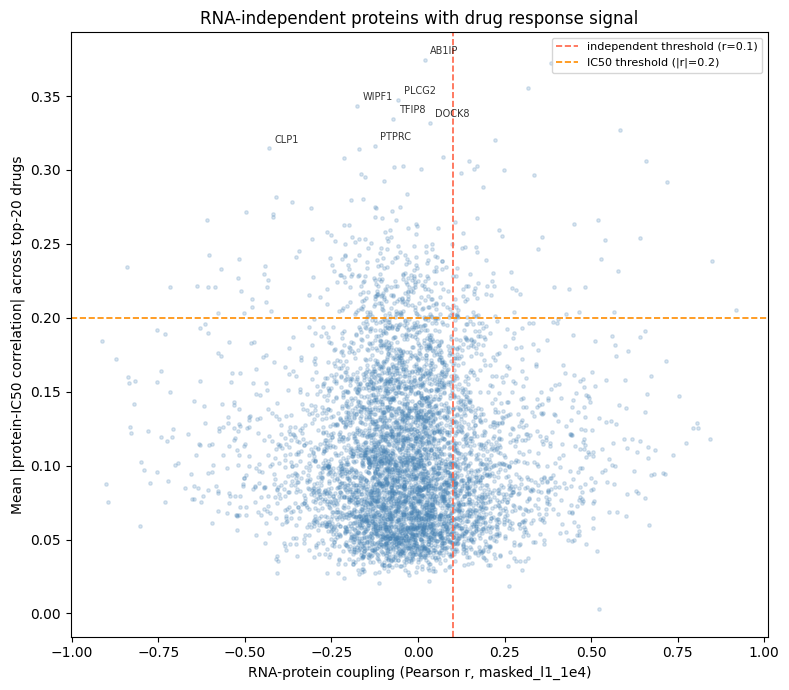

In [35]:
# Scatter: coupling score vs IC50 correlation
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    merged['pearson_r'], merged['ic50_corr'],
    alpha=0.2, s=6, color='steelblue', rasterized=True
)
ax.axvline(INDEPENDENT_R_THRESHOLD, color='tomato',    linewidth=1.2, linestyle='--',
           label=f'independent threshold (r={INDEPENDENT_R_THRESHOLD})')
ax.axhline(IC50_CORR_THRESHOLD,     color='darkorange', linewidth=1.2, linestyle='--',
           label=f'IC50 threshold (|r|={IC50_CORR_THRESHOLD})')

for _, row in high_dev_drug_relevant.head(10).iterrows():
    ax.annotate(
        row['gene'],
        xy=(row['pearson_r'], row['ic50_corr']),
        fontsize=7, alpha=0.8,
        xytext=(4, 4), textcoords='offset points'
    )

ax.set_xlabel('RNA-protein coupling (Pearson r, masked_l1_1e4)')
ax.set_ylabel('Mean |protein-IC50 correlation| across top-20 drugs')
ax.set_title('RNA-independent proteins with drug response signal')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'coupling_vs_ic50_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

## Summary

In [36]:
print('=' * 60)
print('nb16 SUMMARY')
print('=' * 60)
print(f'Total proteins analysed:         {len(protein_df_full):,}')
print()
for cls in ['coupled', 'intermediate', 'independent']:
    n = (protein_df_full['coupling_class'] == cls).sum()
    print(f'  {cls:15s}: {n:,} ({n/len(protein_df_full)*100:.1f}%)')
print()
print(f'Tissues profiled:                {len(tissue_coupling):,}')
lowest  = tissue_coupling.index[0]
highest = tissue_coupling.index[-1]
print(f'Lowest  coupling tissue:         {lowest} '
      f'(r={tissue_coupling.loc[lowest, "median_coupling_r"]:.3f})')
print(f'Highest coupling tissue:         {highest} '
      f'(r={tissue_coupling.loc[highest, "median_coupling_r"]:.3f})')
print()
print(f'RNA-independent + drug-relevant: {len(high_dev_drug_relevant):,} proteins')
print(f'  IC50 threshold used: mean |r| >= {IC50_CORR_THRESHOLD} across top-{TOP_DRUGS_N} drugs')
print()
print('Outputs saved to:', RESULTS_DIR)
print('  protein_classification.csv')
print('  tissue_coupling_profile.csv')
print('  high_deviation_drug_relevant.csv')

nb16 SUMMARY
Total proteins analysed:         6,651

  coupled        : 338 (5.1%)
  intermediate   : 910 (13.7%)
  independent    : 5,403 (81.2%)

Tissues profiled:                23
Lowest  coupling tissue:         Head And Neck (r=0.352)
Highest coupling tissue:         Blood (r=0.472)

RNA-independent + drug-relevant: 322 proteins
  IC50 threshold used: mean |r| >= 0.2 across top-20 drugs

Outputs saved to: /content/drive/MyDrive/multiomics_project/results/deviation
  protein_classification.csv
  tissue_coupling_profile.csv
  high_deviation_drug_relevant.csv
